In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from glob import glob
from tqdm import tqdm

import bipolarity as b
import utils

from neuron_morphology.swc_io import morphology_from_swc
import matplotlib.pyplot as plt
%matplotlib inline

/opt/conda/lib/python3.10/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.0.3) or chardet (6.0.0.post1)/charset_normalizer (3.2.0) doesn't match a supported version!
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
df = pd.read_csv("/scratch/LC_soma_shapes.csv", index_col="id")
df.head()


,soma,soma_offset,radii,volume,rsquared,primary_axis,path,brain
id,,,,,,,,
N015-721332,[14495.064453 11131.75 12876.399414],[ -1.7952 7.7792 -20. ],[21.38663339 28.63718906 67.23518265],172487.651793,0.821708,[0.9772183 0.18816464 0.09817571],/data/exaSPIM_721332_2025-04-05_14-48-36_recon...,721332
N013-721332,[13786. 10565. 13460.],[-13.464 -2.618 -19. ],[17.95036715 37.67477643 79.66366969],225669.536659,0.621483,[0.95450145 0.23402791 0.18481864],/data/exaSPIM_721332_2025-04-05_14-48-36_recon...,721332
N012-721332,[14564. 11331. 13737.],[ 2.6928 -4.7872 8.8 ],[25.58151856 29.85705294 80.48071718],257486.051033,0.785581,[-0.93634273 -0.16083758 -0.31207941],/data/exaSPIM_721332_2025-04-05_14-48-36_recon...,721332
N002-721332,[13958. 10947. 14180.],[ 4.896 -7.344 1.81818182],[15.67191192 40.44252637 67.78597955],179965.287707,0.699839,[-0.60523823 0.77619909 -0.17663991],/data/exaSPIM_721332_2025-04-05_14-48-36_recon...,721332
N020-721332,[13143.365234 15708.287109 11853.829101],[ -8.228 1.87 -16. ],[15.32568895 32.83569028 70.31241995],148213.175385,0.583251,[ 0.94939694 -0.03429497 0.31220073],/data/exaSPIM_721332_2025-04-05_14-48-36_recon...,721332


In [3]:
# use swc with soma ID corrected
# df.loc["N016-685221", "path"] = "/data/N016-685221-PG.swc"

In [4]:

for col in ["radii", "primary_axis", "soma_offset", "soma"]:
    df[col] = df[col].fillna("[NaN NaN NaN]")
    df[col] = df[col].str.replace(r"\[\s*|\s*\]", "", regex=True).str.split(r"\s+")
    # move column of lists to separate columns
    df = df.assign(
        **{f"{col}_{i}": df[col].apply(lambda x: float(x[i])) for i in range(3)}
    )


In [5]:
from collections import OrderedDict
def intersection_points(m, cutoff = 100):
    root = m.get_root()
    hits = OrderedDict()
    record = {}
    # hits[root["id"]] = root
    def visit(node):
        # c = m.get_compartment_for_node(node)
        # if c is None:
        #     return
        # if (cutoff > m.euclidean_distance(root, c[0]) and cutoff < m.euclidean_distance(root, c[1])):
            # hits[node["id"]] = c[0]
        record["stop"] = False
        if node["type"]==1:
            return
        if node["type"]==3:
            is_second_branch = len(m.get_children(node)) > 1
            if cutoff < m.euclidean_distance(root, node) or is_second_branch:
                hits[node["id"]] = node
                record["stop"] = True
        else:
            # not dendrite or soma
            record["stop"] = True
        return
    def cb(node_id):
        if record["stop"]:
            # stop traversal
            return []
        else:
            nested_ids = m.child_ids([node_id])
            children = [nid for nids in nested_ids for nid in nids]
            if len(children) > 1:
                record["branch_root"] = node_id
            return children

    m.breadth_first_traversal(visit, cb)
    return hits

def get_bipolarity(soma, stems, primary_axis, cos2_cutoff=0.5):
    val = 0.0
    aligned_avg = 0.0
    avg0 = np.array([0,0,0])
    avg1 = np.array([0,0,0])
    avg2 = np.array([0,0,0])
    # cos2_vals = []
    n = len(stems)
    primary_axis = np.array(primary_axis)
    primary_axis = primary_axis / np.linalg.norm(primary_axis)
    vecs = []
    for stem in stems.values():
        vec = np.array([float(stem[i]) for i in "xyz"]) - np.array(soma)
        vec = vec / np.linalg.norm(vec)
        vecs.append(vec.astype(float))

        avg0 = avg0 + (vec * np.sign(vec[0])/n)
        avg1 = avg1 + (vec * np.sign(vec[1])/n)
        avg2 = avg2 + (vec * np.sign(vec[2])/n)
        aligned = np.abs(np.dot(vec, primary_axis))
        aligned_avg += aligned/n
        if aligned**2 > cos2_cutoff:
            val += 1.0/n
    vectors = np.array(vecs)
    S = vectors.T @ vectors / len(vectors)
    eigenvalues, eigenvectors = np.linalg.eigh(S)
    avg, norm_avg = eigenvectors[:, 2], np.sqrt(eigenvalues[2])
    # avg_candidates = [avg0, avg1, avg2]
    # avg = max(avg_candidates, key=lambda x: np.linalg.norm(x))
    # norm_avg = np.linalg.norm(avg)
    # abs_cos = np.abs(np.dot(avg, primary_axis))/norm_avg
    abs_cos = np.abs(np.dot(avg, primary_axis))
    return val, aligned_avg, norm_avg, abs_cos

In [6]:

# names = ["aligned_bipolar_frac","aligned_bipolarity","abs_bipolarity", "cos_primary_axis"]
# names_offset = [x+"_offset" for x in names]
# df[names] = None
# df[names_offset] = None
# df["num_stems"] = None
# # cos2_vals = []
# # cos2_vals_offset = []
# index = []
# for swc in tqdm(glob("/data/lc_image_space_reconstructions/*/*.swc")[:]):
#     id = swc.split("/")[-1][:11]
#     if id not in df.index:
#         # print(f"missing {id}")
#         continue
#     index.append(id)
#     morph = morphology_from_swc(swc)
#     # morph_soma = [morph.get_soma()[i] for i in "xyz"]
#     # morph soma == spreadsheet soma

#     r2 = float(df.loc[id, "radii_2"])
#     r2 = 50
#     stems = intersection_points(morph, cutoff=r2)
#     df.loc[id, "num_stems"] = len(stems)

#     soma = df.loc[id, [f"soma_{i}" for i in range(3)]].values
#     primary_axis = df.loc[id, [f"primary_axis_{i}" for i in range(3)]].values
#     df.loc[id, names] = get_bipolarity(soma, stems, primary_axis, cos2_cutoff=0.5)
#     # cos2_vals.append(vals)

#     offset_soma = soma + df.loc[id, [f"soma_offset_{i}" for i in range(3)]].values
#     df.loc[id, names_offset] = get_bipolarity(offset_soma, stems, primary_axis, cos2_cutoff=0.5)
#     # cos2_vals_offset.append(vals)


In [7]:
from importlib import reload
reload(b)

<module 'bipolarity' from '/code/bipolarity.py'>

In [8]:
# id = "N016-685221"
# swc = "/data/N016-685221-PG.swc"
# morph = morphology_from_swc(swc)
# r2 = 50
# stems = b.intersection_points(morph, cutoff=r2)
# stems

In [9]:
names = ["aligned_bipolar_frac","aligned_bipolarity","abs_bipolarity", "cos_primary_axis"]
names_offset = [x+"_offset" for x in names]
df[names] = None
df[names_offset] = None
df["num_stems"] = None

for id in tqdm(df.index):
    swc = df.loc[id, "path"]
    morph = utils.morphology_from_swc(swc)
    # r2 = float(df.loc[id, "radii_2"])
    r2 = 50
    stems = b.intersection_points(morph, cutoff=r2)

    # soma = df.loc[id, [f"soma_{i}" for i in range(3)]].values
    soma = [morph.get_soma()[i] for i in "xyz"]
    # morph soma == spreadsheet soma
    try:
        if np.isnan(df.loc[id, "volume"]):
            df.loc[id, "abs_bipolarity"] = b.get_dend_bipolarity(soma, stems)

        else:
            primary_axis = df.loc[id, [f"primary_axis_{i}" for i in range(3)]].values
            df.loc[id, names] = b.get_bipolarity(soma, stems, primary_axis, cos2_cutoff=0.5)
            # cos2_vals.append(vals)

            offset_soma = soma + df.loc[id, [f"soma_offset_{i}" for i in range(3)]].values
            df.loc[id, names_offset] = b.get_bipolarity(offset_soma, stems, primary_axis, cos2_cutoff=0.5)
            # cos2_vals_offset.append(vals)
    except np.linalg.LinAlgError as e:
        print(f"Cell {id} failed: {e}")
    
    df.loc[id, "num_stems"] = len(stems)


100%|██████████| 131/131 [01:24<00:00,  1.55it/s]


In [10]:

print(f'{df["aligned_bipolarity"].notna().sum()=}')
print(f'{df["abs_bipolarity"].notna().sum()=}')

df["aligned_bipolarity"].notna().sum()=123
df["abs_bipolarity"].notna().sum()=131


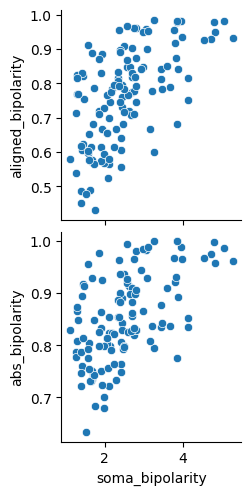

In [11]:
r_mean = np.linalg.norm(df[["radii_0","radii_1"]], axis=1)
r_mean = np.sqrt(df["radii_0"] * df["radii_1"])
r_mean = df["radii_1"]
df["soma_bipolarity"] = df["radii_2"] / r_mean
df["soma_bipolarity_coeff"] = (df["radii_2"] - r_mean)/df["radii_2"]
# df["soma_bipolarity"] = df["radii_2"] / np.sqrt(df["radii_0"]*df["radii_1"])

sns.pairplot(df, y_vars=["aligned_bipolarity", "abs_bipolarity"], x_vars=["soma_bipolarity",])
# "soma_bipolarity_coeff"

In [12]:
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

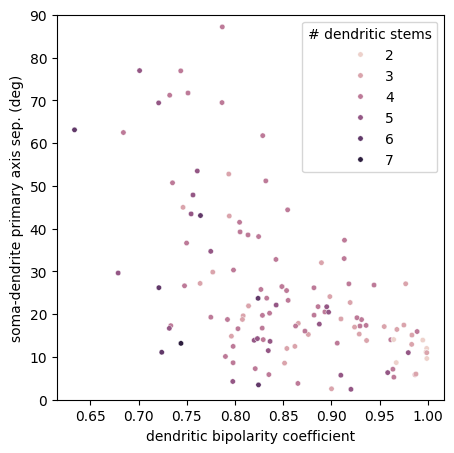

In [13]:
df["primary_axis_angle"] = df["cos_primary_axis"].map(np.arccos).map(np.degrees)

fig = plt.figure(figsize=(5,5))
sns.scatterplot(data=df, y="primary_axis_angle", x="abs_bipolarity", hue="num_stems", s=15)
plt.xlabel("dendritic bipolarity coefficient")
plt.ylabel("soma-dendrite primary axis sep. (deg)")
plt.ylim(0,90)
# legend title
plt.legend(title="# dendritic stems")

In [14]:
# outliers
pd.set_option('display.max_columns', None)
df.query("primary_axis_angle>40 & soma_bipolarity>3")

,soma,soma_offset,radii,volume,rsquared,primary_axis,path,brain,radii_0,radii_1,radii_2,primary_axis_0,primary_axis_1,primary_axis_2,soma_offset_0,soma_offset_1,soma_offset_2,soma_0,soma_1,soma_2,aligned_bipolar_frac,aligned_bipolarity,abs_bipolarity,cos_primary_axis,aligned_bipolar_frac_offset,aligned_bipolarity_offset,abs_bipolarity_offset,cos_primary_axis_offset,num_stems,soma_bipolarity,soma_bipolarity_coeff,primary_axis_angle
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
N008-721332,"[14999., 11292., 13360.]","[-10.68571429, 5.12914286, -22.28571429]","[27.0702694, 30.65475778, 99.55108744]",346039.028686,0.791909,"[0.99112358, 0.11837335, 0.06051286]",/data/exaSPIM_721332_2025-04-05_14-48-36_recon...,721332,27.070269,30.654758,99.551087,0.991124,0.118373,0.060513,-10.685714,5.129143,-22.285714,14999.0,11292.0,13360.0,0.0,0.60028,0.79398,0.732042,0.0,0.622801,0.668207,0.998324,3,3.247492,0.69207,42.942148


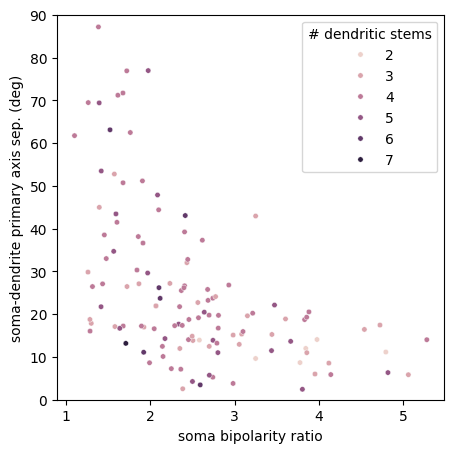

In [15]:

plt.figure(figsize=(5,5))
sns.scatterplot(data=df, y="primary_axis_angle", x="soma_bipolarity", hue="num_stems", s=15)
plt.xlabel("soma bipolarity ratio")
plt.ylabel("soma-dendrite primary axis sep. (deg)")
plt.ylim(0,90)
# legend title
plt.legend(title="# dendritic stems")

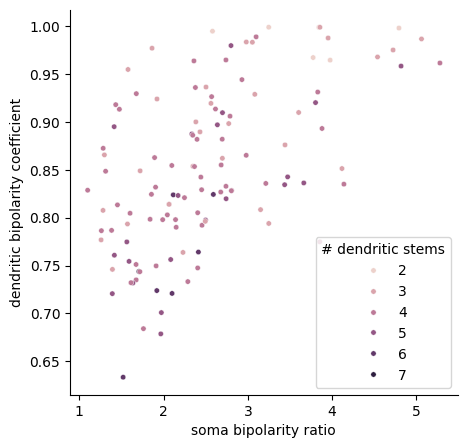

In [16]:
plt.figure(figsize=(5,5))
sns.scatterplot(data=df, x="soma_bipolarity", y="abs_bipolarity", hue="num_stems", s=15)
plt.ylabel("dendritic bipolarity coefficient")
plt.xlabel("soma bipolarity ratio")
plt.legend(title="# dendritic stems")
sns.despine()
plt.savefig("/scratch/soma_vs_dend_bipolarity.pdf")
plt.savefig("/scratch/soma_vs_dend_bipolarity.svg")

Two bipolarity coefficients are highly correlated - we can aggregate them via harmonic mean to a single coefficient

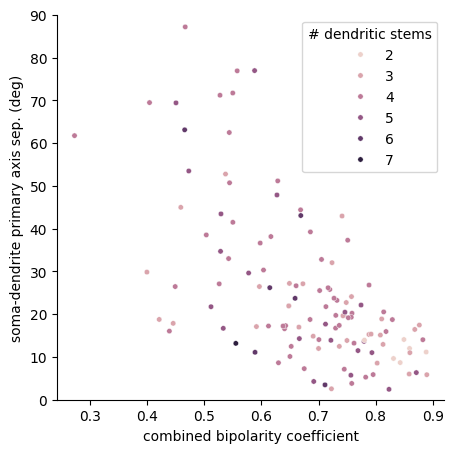

In [17]:

df["bipolarity"] = np.sqrt(df["abs_bipolarity"] * df["soma_bipolarity_coeff"])
plt.figure(figsize=(5,5))
sns.scatterplot(data=df, y="primary_axis_angle", x="bipolarity", hue="num_stems", s=15)
plt.xlabel("combined bipolarity coefficient")
plt.ylabel("soma-dendrite primary axis sep. (deg)")
plt.ylim(0,90)
# legend title
plt.legend(title="# dendritic stems")
sns.despine()
plt.savefig("/scratch/bipolarity_axis_separation.pdf")
plt.savefig("/scratch/bipolarity_axis_separation.svg")

In [18]:
df.query("bipolarity<0.3")

,soma,soma_offset,radii,volume,rsquared,primary_axis,path,brain,radii_0,radii_1,radii_2,primary_axis_0,primary_axis_1,primary_axis_2,soma_offset_0,soma_offset_1,soma_offset_2,soma_0,soma_1,soma_2,aligned_bipolar_frac,aligned_bipolarity,abs_bipolarity,cos_primary_axis,aligned_bipolar_frac_offset,aligned_bipolarity_offset,abs_bipolarity_offset,cos_primary_axis_offset,num_stems,soma_bipolarity,soma_bipolarity_coeff,primary_axis_angle,bipolarity
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
N057-685221,"[31712., 9807., 11156.]","[-8.976, 2.65955556, -8.88888889]","[16.43488483, 43.69198499, 47.9880494]",144341.145444,0.641888,"[-0.82547551, 0.40510294, -0.39304171]",/data/exaSPIM_685221_2024-04-12_11-46-38_recon...,685221,16.434885,43.691985,47.988049,-0.825476,0.405103,-0.393042,-8.976,2.659556,-8.888889,31712.0,9807.0,11156.0,0.0,0.579491,0.82867,0.473492,0.0,0.661289,0.831966,0.663989,4,1.098326,0.089524,61.738765,0.27237


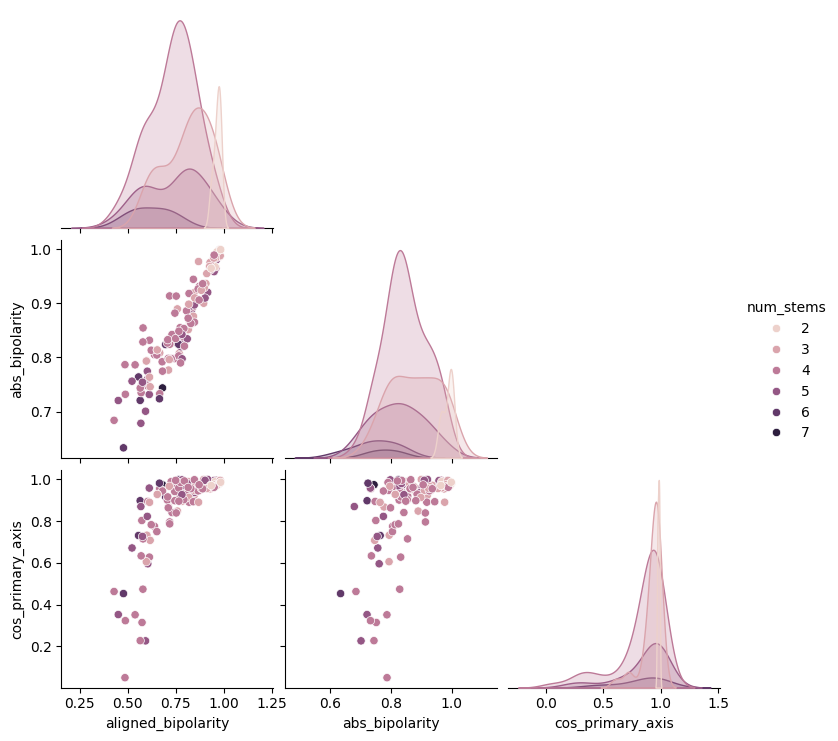

In [19]:
names = ["aligned_bipolarity","abs_bipolarity", "cos_primary_axis"]
# df.loc[index, "mean_bipolarity"] = [np.mean(np.sqrt(np.array(x))) for x in cos2_vals]
# df.loc[index, "mean_bipolarity_offset"] = [np.mean(np.sqrt(np.array(x))) for x in cos2_vals_offset]
sns.pairplot(df, vars=names, corner=True, hue="num_stems")

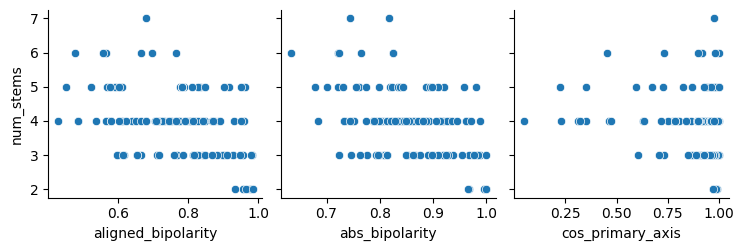

In [20]:

# df.loc[index, "mean_bipolarity"] = [np.mean(np.sqrt(np.array(x))) for x in cos2_vals]
# df.loc[index, "mean_bipolarity_offset"] = [np.mean(np.sqrt(np.array(x))) for x in cos2_vals_offset]
sns.pairplot(df, y_vars=["num_stems"], x_vars=names)

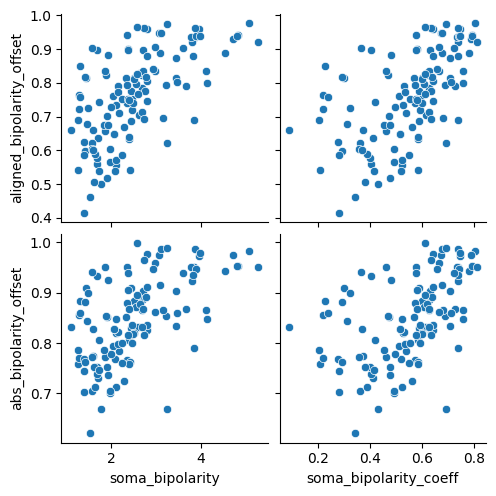

In [21]:
sns.pairplot(df, y_vars=["aligned_bipolarity_offset", "abs_bipolarity_offset"], x_vars=["soma_bipolarity","soma_bipolarity_coeff"])

# CCF coords from csv

In [49]:
from importlib import reload
reload(utils)

<module 'utils' from '/code/utils.py'>

In [50]:

from neuron_morphology.feature_extractor.feature_extractor import FeatureExtractor
from neuron_morphology.swc_io import morphology_from_swc
from neuron_morphology.feature_extractor.data import Data
from neuron_morphology.features.size import total_length
from neuron_morphology.feature_extractor.marked_feature import specialize
from neuron_morphology.feature_extractor.feature_specialization import AxonSpec, DendriteSpec, BasalDendriteSpec

import logging
logging.getLogger().setLevel(logging.WARNING)

features = [
    specialize(total_length, {AxonSpec, DendriteSpec})
]

records = []
for id in tqdm(df.index[:]):
    # try:
        swc = glob(f"/data/exaSPIM*reconstructions*/ccf_space_reconstructions/swc/{id}*.swc")[0]
        # swc = df.loc[id, "path"]
        # morph = utils.load_morphology(swc, axon_radius=np.inf)
        morph, soma = utils.load_morphology_and_soma(swc, axon_radius=1e9, trim_to_ccf=False)
        extractor = FeatureExtractor(features)
        run = extractor.extract(
            Data(morph)
        )
        records.append(dict(id=id, **run.results, **{i: soma[i] for i in "xyz"}))
    # except Exception as e:
    #     print(f"error {e} for cell {id}")

100%|██████████| 131/131 [05:20<00:00,  2.44s/it]


In [51]:
df_summary = pd.DataFrame.from_records(records, index="id")
coords = ["somaML","somaDV","somaAP"][::-1]
df_summary[coords] = df_summary[["x","y","z"]]
df_summary.head()

,axon.total_length,dendrite.total_length,x,y,z,somaAP,somaDV,somaML
id,,,,,,,,
N015-721332,276837.559450,3824.861855,10424.193256,4099.782597,4933.680427,10424.193256,4099.782597,4933.680427
N013-721332,517012.262358,751.491792,10701.885938,4278.447336,4664.833268,10701.885938,4278.447336,4664.833268
N012-721332,319989.698738,3855.481450,10325.589894,4491.749204,4909.626929,10325.589894,4491.749204,4909.626929
N002-721332,204022.003164,2952.642536,10608.095126,4651.070670,4706.527206,10608.095126,4651.070670,4706.527206
N020-721332,369755.856019,3439.126121,10847.172434,4211.961829,4553.497384,10847.172434,4211.961829,4553.497384


In [52]:
# cols = ["x","y","z"] + coords
# df_summary[cols] = df_summary[cols].applymap(lambda x: x.values[0])
# df_summary.head()

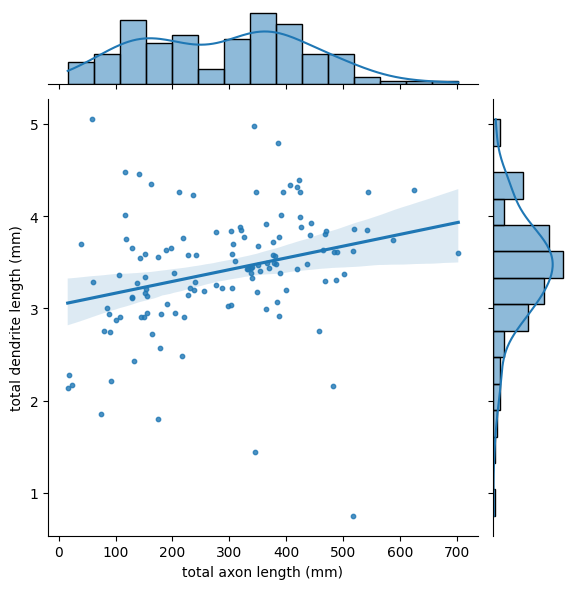

In [53]:
savefig_kw={'bbox_inches':'tight', 'pad_inches':0}
df_plot = df_summary.query("somaDV<5500 & somaML>4300").copy()
df_plot = df_plot[df_plot["dendrite.total_length"]<6000]
x, y = "axon.total_length", "dendrite.total_length"
df_plot[[x,y]] *= 1e-3
# df_plot = df_merged
sns.jointplot(df_plot, x=x, y=y,
    scatter_kws=dict(s=10), kind="reg",
    marginal_kws=dict(bins=15))

plt.xlabel("total axon length (mm)")
plt.ylabel("total dendrite length (mm)")

plt.savefig(f"/scratch/dend_vs_axon.pdf")
plt.savefig(f"/scratch/dend_vs_axon.svg", **savefig_kw)

In [54]:
df_summary.loc[lambda df: df['dendrite.total_length']>6000]

,axon.total_length,dendrite.total_length,x,y,z,somaAP,somaDV,somaML
id,,,,,,,,
N026-648434,41806.129276,6267.738882,9996.080796,6030.793581,4081.026776,9996.080796,6030.793581,4081.026776


In [55]:
# import trimesh
# # 
# # Load mesh
# mesh = trimesh.load('/root/capsule/data/lc_meshes/20250418_transformed_remesh_10.obj')

In [56]:
from vedo.file_io import load_obj

# Load mesh
mesh = load_obj('/root/capsule/data/LC_percentile_meshes/new_core_mesh.obj')[0]
mesh.vertices = mesh.vertices[:,(1,2,0)]

In [57]:
# df_summary = pd.read_csv("/data/LC Morphology Summary.csv")
# df_summary.index = df_summary["Graph"].str[:-3]
df_merged = df.merge(df_summary, left_index=True, right_index=True)
df_merged.columns

Index(['soma', 'soma_offset', 'radii', 'volume', 'rsquared', 'primary_axis',
       'path', 'brain', 'radii_0', 'radii_1', 'radii_2', 'primary_axis_0',
       'primary_axis_1', 'primary_axis_2', 'soma_offset_0', 'soma_offset_1',
       'soma_offset_2', 'soma_0', 'soma_1', 'soma_2', 'aligned_bipolar_frac',
       'aligned_bipolarity', 'abs_bipolarity', 'cos_primary_axis',
       'aligned_bipolar_frac_offset', 'aligned_bipolarity_offset',
       'abs_bipolarity_offset', 'cos_primary_axis_offset', 'num_stems',
       'soma_bipolarity', 'soma_bipolarity_coeff', 'primary_axis_angle',
       'bipolarity', 'axon.total_length', 'dendrite.total_length', 'x', 'y',
       'z', 'somaAP', 'somaDV', 'somaML'],
      dtype='object')

In [58]:
df.index.difference(df_summary.index)

Index([], dtype='object', name='id')

In [59]:
df_summary.index.difference(df.index)

Index([], dtype='object', name='id')

### spatial plots

In [60]:
import utils
from importlib import reload
reload(utils)

savefig_kw={'bbox_inches':'tight', 'pad_inches':0}

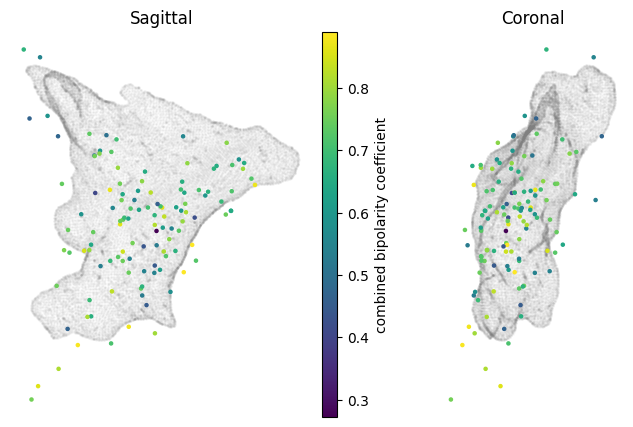

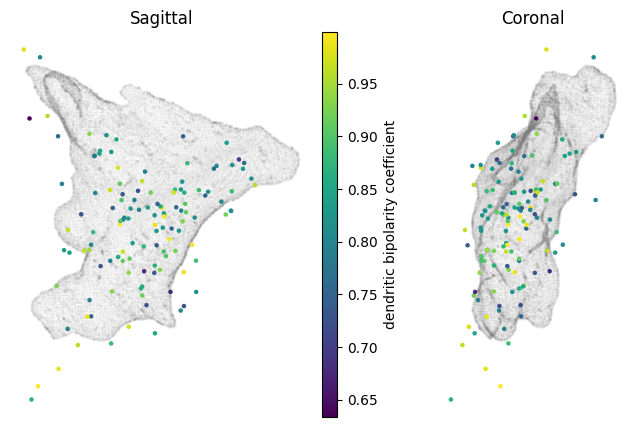

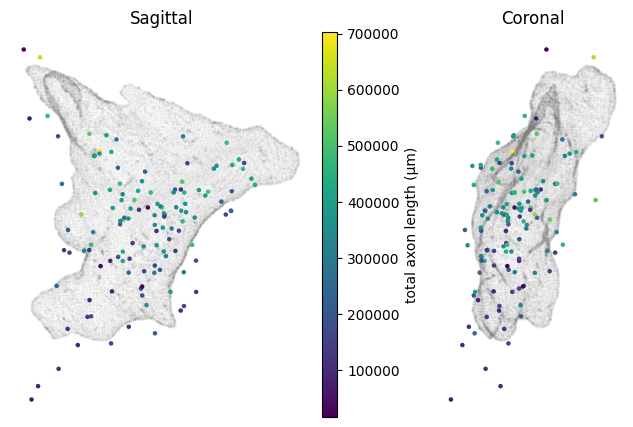

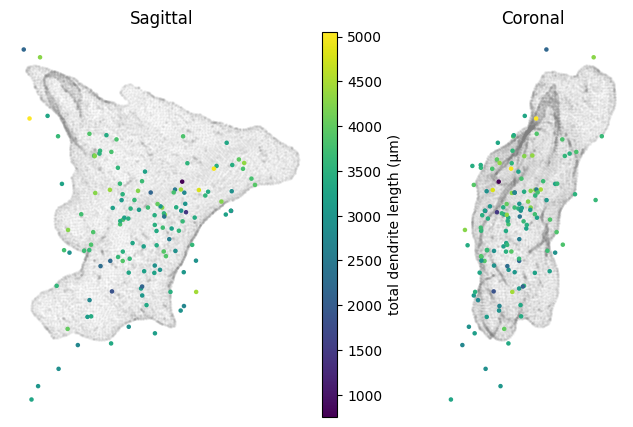

In [61]:
coords = ["somaML","somaDV","somaAP"][::-1]
df_plot = df_merged.query("somaDV<5500 & somaML>4300")
# print(f"{len(df_plot)=}")
cols = [
    "bipolarity", 
    "abs_bipolarity", 
    # "Dendrite Length (cm)",
    # "Axon Length (cm)",
    "axon.total_length",
    "dendrite.total_length",
]
labels = [
    "combined bipolarity coefficient",
    "dendritic bipolarity coefficient",
    "total axon length (μm)",
    "total dendrite length (μm)",
]
for col, label in zip(cols, labels):
    utils.two_view_plot_df(df_plot, col, coords, label=label, mesh=mesh, s=5)
    plt.savefig(f"/scratch/spatialplot-{col}.pdf")
    plt.savefig(f"/scratch/spatialplot-{col}.svg", **savefig_kw)

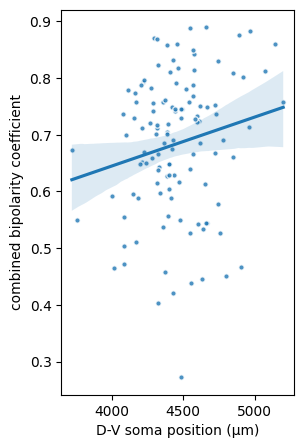

In [62]:
# downward in refs (reverse)
plt.figure(figsize=(3,5))
x="somaDV"
y="bipolarity"
# sns.regplot(data=df_merged.query("somaDV<5500"), y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})
# sns.regplot(data=df_merged.query("somaDV<5500 & somaML>4300"), y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})
sns.regplot(data=df_plot, y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})
plt.ylabel("combined bipolarity coefficient")
plt.xlabel("D-V soma position (μm)")
plt.savefig(f"/scratch/regression_{x}-{y}.svg")

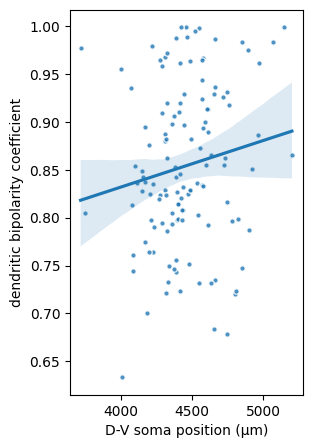

In [63]:
# downward in refs (reverse)
plt.figure(figsize=(3,5))
x="somaDV"
y="abs_bipolarity"
# sns.regplot(data=df_merged.query("somaDV<5500"), y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})
sns.regplot(data=df_plot, y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})
plt.ylabel("dendritic bipolarity coefficient")
plt.xlabel("D-V soma position (μm)")
plt.savefig(f"/scratch/regression_{x}-{y}.svg")

<Axes: xlabel='somaAP', ylabel='bipolarity'>

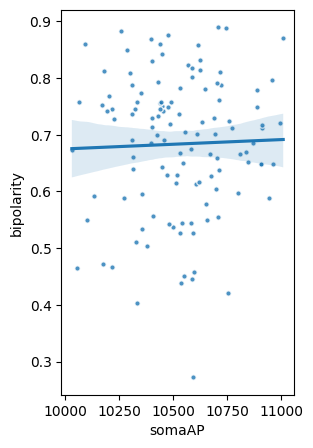

In [64]:
# increasing in refs
plt.figure(figsize=(3,5))
x="somaAP"
y="bipolarity"
plt.ylabel("combined bipolarity coefficient")
plt.xlabel("A-P soma position (μm)")
sns.regplot(data=df_plot, y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})

Text(0.5, 0, 'A-P soma position (μm)')

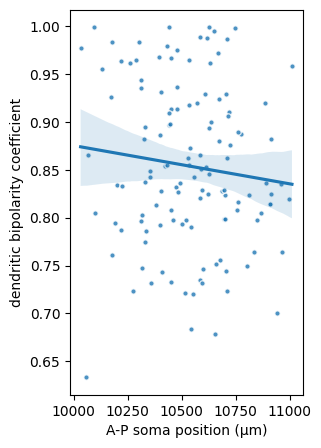

In [65]:
# increasing in refs (reverse)
plt.figure(figsize=(3,5))
x="somaAP"
y="abs_bipolarity"
sns.regplot(data=df_plot, y=y, x=x, scatter_kws={"s": 15, "edgecolor": "w"})
plt.ylabel("dendritic bipolarity coefficient")
plt.xlabel("A-P soma position (μm)")

## figure composition

In [66]:
import svgutils.compose as svg
i=-1
letters = "abcdefghijkl"
def panel(path, scale=1): 
    global i
    i+=1
    return svg.Panel(svg.SVG(path).scale(scale), svg.Text(letters[i], 10, 10, size=14, weight='bold'))

dx = 200
fig = svg.Figure(*100*np.array([7, 8.5]),
    svg.Panel(
        panel("/scratch/soma_vs_dend_bipolarity.svg", 0.7),
        panel("/scratch/spatialplot-abs_bipolarity.svg", 0.7).move(225,0),
        panel("/scratch/regression_somaDV-abs_bipolarity.svg", 0.7).move(550,0),
    ),
    svg.Panel(
        panel("/scratch/bipolarity_axis_separation.svg", 0.7),
        panel("/scratch/spatialplot-bipolarity.svg", 0.7).move(225,0),
        panel("/scratch/regression_somaDV-bipolarity.svg", 0.7).move(550,0),
    ),
    svg.Panel(
        panel("/scratch/dend_vs_axon.svg", 0.7),
        panel("/scratch/spatialplot-dendrite.total_length.svg", 0.7).move(300,0),
    )
).tile(1,3)
fig.save("/scratch/supp_somatodendritic_combined.svg")